In [4]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
#loading the dataset
df=pd.read_csv("../data/raw/gold_prices.csv")
df.head()



,Date,Close,High,Low,Open,Volume
0,2016-01-04,1075.099976,1082.500000,1063.199951,1063.400024,143
1,2016-01-05,1078.400024,1081.500000,1075.300049,1075.599976,82
2,2016-01-06,1091.900024,1093.699951,1081.599976,1081.599976,52
3,2016-01-07,1107.699951,1109.400024,1091.599976,1091.599976,122
4,2016-01-08,1097.800049,1111.099976,1093.000000,1111.099976,98


In [6]:
#Columns presented
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2636 entries, 0 to 2635
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2636 non-null   str    
 1   Close   2636 non-null   float64
 2   High    2636 non-null   float64
 3   Low     2636 non-null   float64
 4   Open    2636 non-null   float64
 5   Volume  2636 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 123.7 KB


In [8]:
#number of rows*columns
df.shape

(2636, 6)

In [9]:
df.describe()

,Close,High,Low,Open,Volume
count,2636.000000,2636.000000,2636.000000,2636.000000,2636.000000
mean,1966.106826,1976.864113,1955.058992,1965.969842,5101.193475
std,890.168373,899.440283,881.132336,891.038738,28039.023753
min,1073.900024,1081.500000,1063.199951,1063.400024,0.000000
25%,1308.174957,1311.524994,1304.449951,1308.199951,55.000000
50%,1777.750000,1788.250000,1771.100037,1779.900024,219.500000
75%,2011.825043,2023.675049,2003.024994,2013.975037,683.250000
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


In [10]:
#checking for duplicates values
df.duplicated().sum()

np.int64(0)

In [11]:
#checking for any missing value in each column
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
#checking the data types of columns
df.dtypes

Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [13]:
#convert the datecolumn  to datetime
df["Date"]=pd.to_datetime(df["Date"])

In [14]:
df.dtypes

Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [15]:
df=df.sort_values("Date")

In [16]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,2636,2636.000000,2636.000000,2636.000000,2636.000000,2636.000000
mean,2021-04-01 15:29:46.342943,1966.106826,1976.864113,1955.058992,1965.969842,5101.193475
min,2016-01-04 00:00:00,1073.900024,1081.500000,1063.199951,1063.400024,0.000000
25%,2018-08-19 06:00:00,1308.174957,1311.524994,1304.449951,1308.199951,55.000000
50%,2021-04-03 00:00:00,1777.750000,1788.250000,1771.100037,1779.900024,219.500000
75%,2023-11-13 06:00:00,2011.825043,2023.675049,2003.024994,2013.975037,683.250000
max,2026-06-30 00:00:00,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000
std,NaN,890.168373,899.440283,881.132336,891.038738,28039.023753


<function matplotlib.pyplot.show(close=None, block=None)>

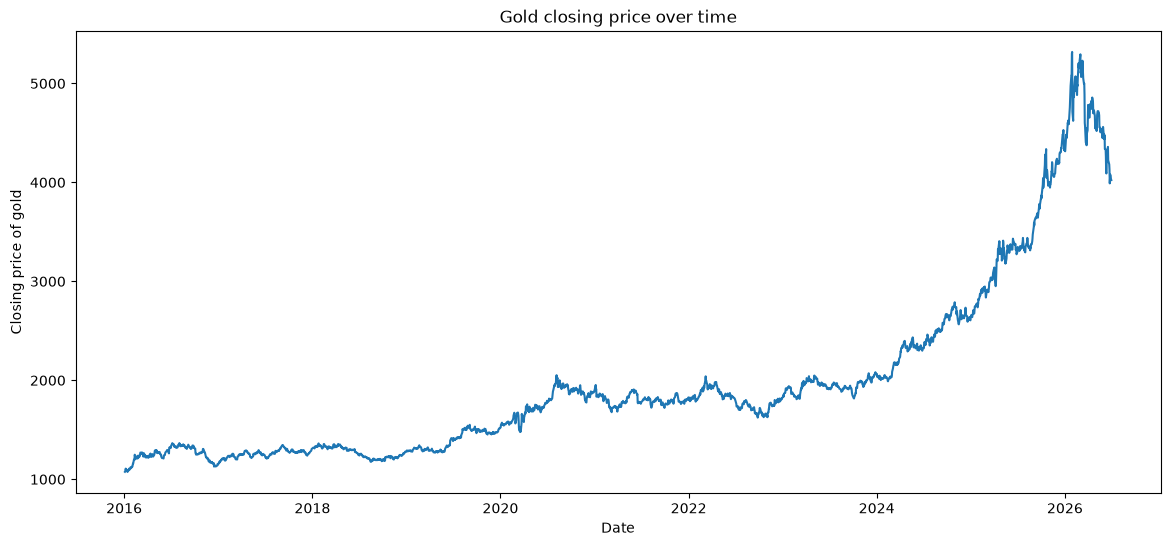

In [17]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Close"])
plt.title("Gold closing price over time")
plt.xlabel("Date")
plt.ylabel("Closing price of gold")
plt.show

#The closing price of gold rised consistently over the years with the highest closing price in 2026
-The closing price shows signs of falling as time goes by

<function matplotlib.pyplot.show(close=None, block=None)>

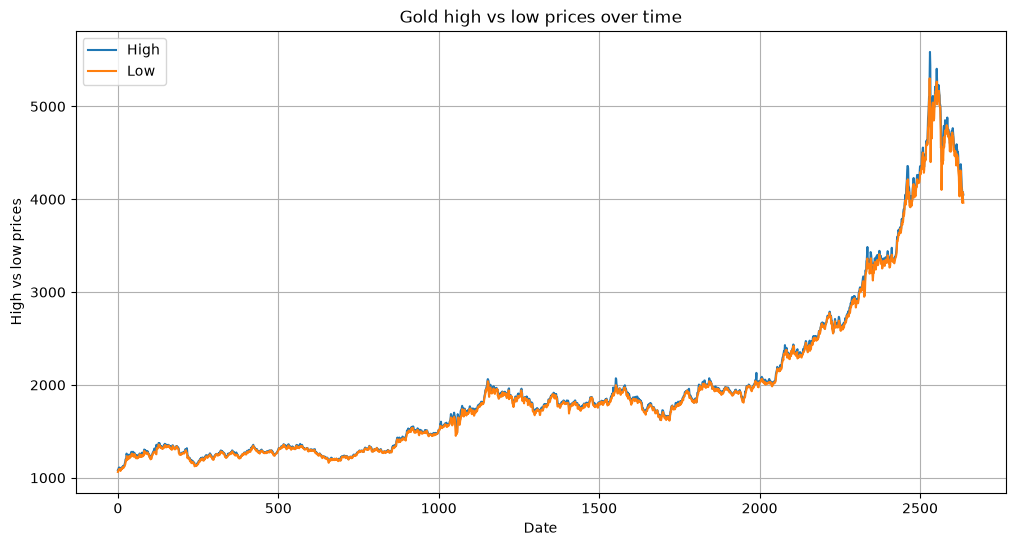

In [18]:
#plotting high vs low prices over time
df[["High","Low"]].plot(figsize=(12,6))
plt.title("Gold high vs low prices over time")
plt.xlabel("Date")
plt.ylabel("High vs low prices")
plt.legend()
plt.grid()
plt.show

#-The daily high prices consistently remained above the daily low prices as expected
-Gold high and lows prices shows consolidation between 2020 and 2024
-Gold begins rapidly rising in 2024  where it reaches its ever max prices in 2026
-Both prices follow a similar trend over time indicating gold prices moved together throughout the period



<function matplotlib.pyplot.show(close=None, block=None)>

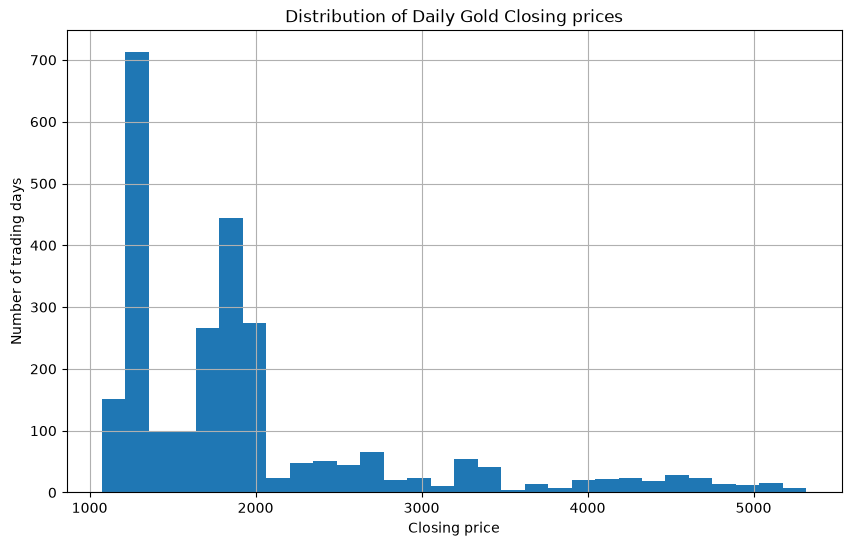

In [19]:
plt.figure(figsize=(10,6))
df["Close"].hist(bins=30)
plt.xlabel("Closing price")
plt.ylabel("Number of trading days")
plt.title("Distribution of Daily Gold Closing prices")
plt.show

#Most closing prices are between 1000 and 2000  due to many number of bars in that range
-There are many trading days within the 1000 to 2000 range
-Between 4000 and 5000 there are few bars indicating few closing prices with few trading days

<Figure size 1000x600 with 0 Axes>

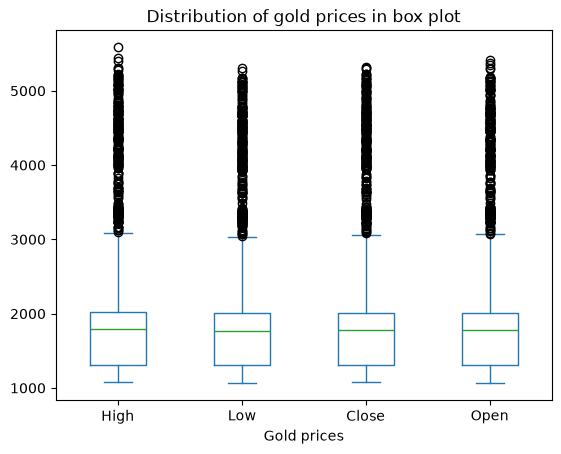

In [20]:
plt.figure(figsize=(10,6))
df[["High","Low","Close","Open"]].plot(kind="box")
plt.title("Distribution of gold prices in box plot")
plt.xlabel("Gold prices")
plt.show()

#The box plot  for the Open,close,high,low prices clearly shows that there are many outliers due to the prices being outside the whisker
-This observation is due to data that is over 10 years and may be caused by market movements and change of price levels

#Perfoming a correction heatmap to know the behaviour between the prices

In [21]:
corr=df.corr(numeric_only=True)

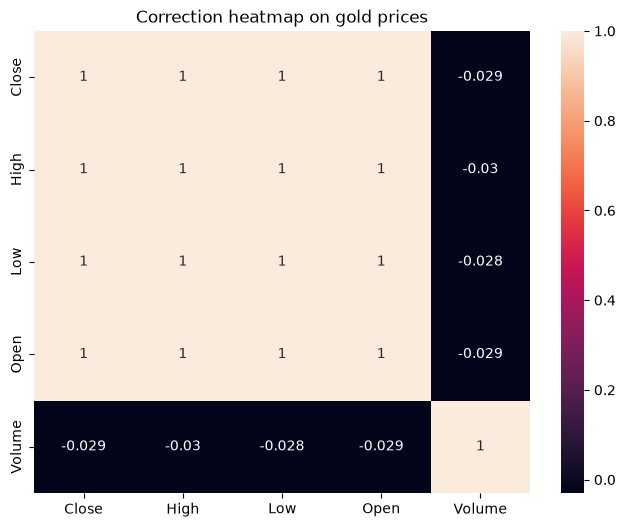

In [22]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True)
plt.title("Correction heatmap on gold prices")
plt.show()


#The correction heatmap clearly shows that open,high,low,close are related and move together over time
The 1 indicates that the prices are perfectly  positively related  together
The volume show a weaker correction with the price variables and indicates no linear relationship with the daily prices


#Feature engineering
-New features are being created from the gold price data for additional market information which improves  exploratory analysis and proviode inputs  useful for predictive models

In [23]:
df["Daily_range"]=df["High"]-df["Low"]
print(df["Daily_range"])

0        19.300049
1         6.199951
2        12.099976
3        17.800049
4        18.099976
           ...    
2631    141.400146
2632     43.800049
2633      0.000000
2634     66.800049
2635     87.199951
Name: Daily_range, Length: 2636, dtype: float64


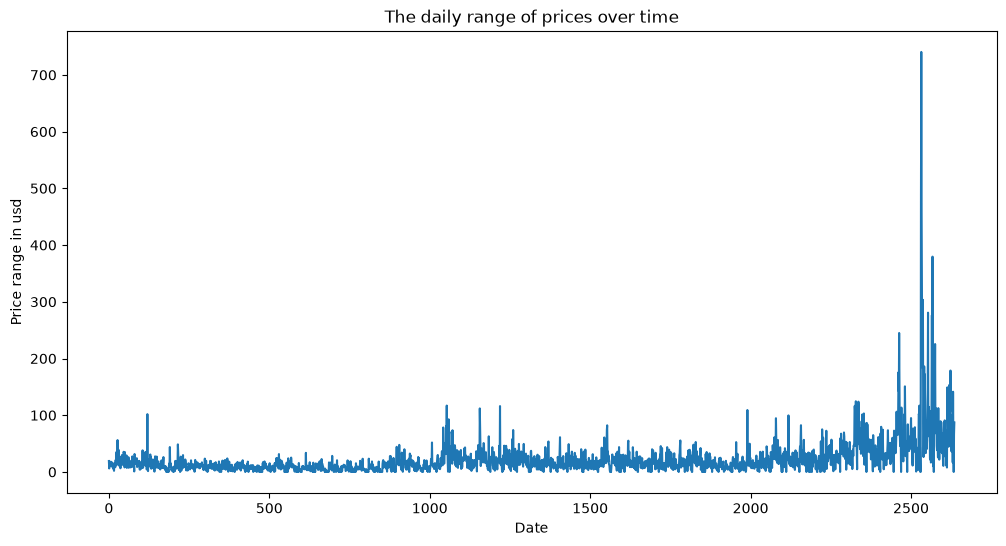

In [24]:
plt.figure(figsize=(12,6))
df["Daily_range"].plot()
plt.title("The daily range of prices over time")
plt.xlabel("Date")
plt.ylabel("Price range in usd")
plt.show()

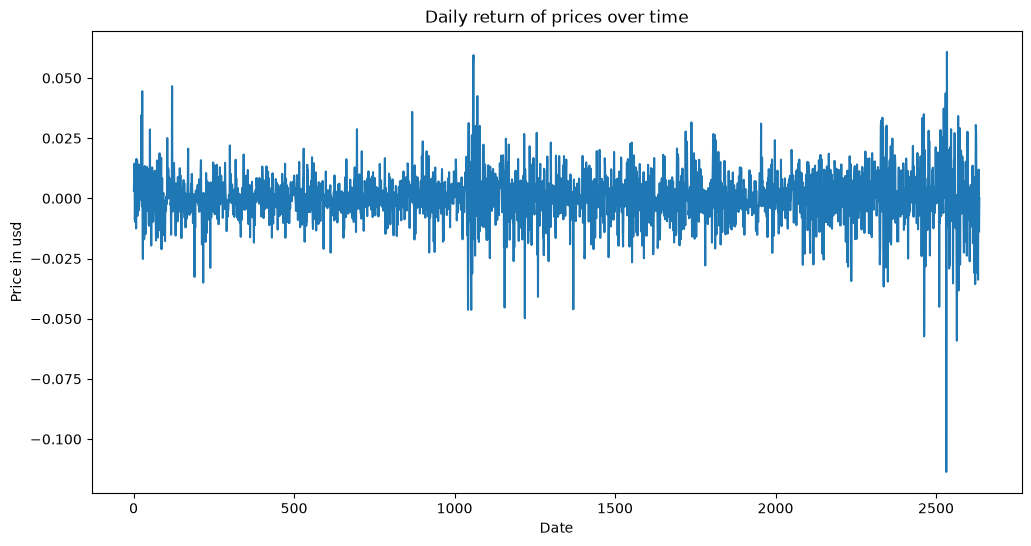

In [25]:
df["Daily_return"]=df["Close"].pct_change()
df[["Close","Daily_return"]].head(5)
plt.figure(figsize=(12,6))
df["Daily_return"].plot()
plt.title(" Daily return of prices over time ")
plt.ylabel("Price in usd")
plt.xlabel("Date")
plt.show()


The daily returns fluctuate around zero, reflecting the day-to-day percentage changes in gold prices. Most returns are relatively small, with occasional spikes indicating periods of increased market volatility.

Creating a moving average of 7

In [26]:
df["7_Ma"]=df["Close"].rolling(window=7).mean()

Creating a moving average of 30

In [27]:
df["30_Ma"]=df["Close"].rolling(window=30).mean()

# Plotting the two moving  averages against time

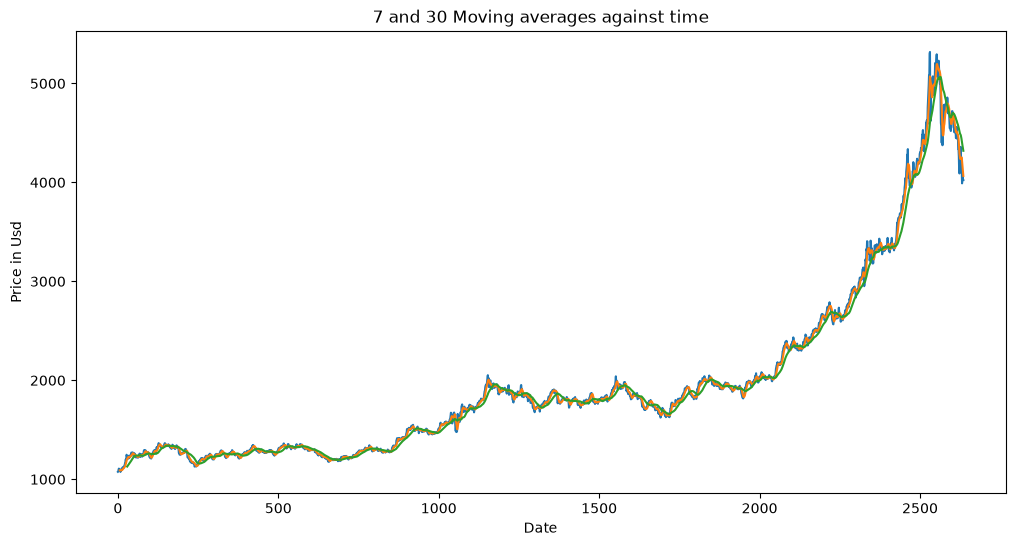

In [28]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"],label="Closing price")
plt.plot(df["7_Ma"],label="7-Day_Ma")
plt.plot(df["30_Ma"],label="30-Day_Ma")
plt.title("7 and 30 Moving averages against time")
plt.xlabel("Date")
plt.ylabel("Price in Usd")
plt.show()

The 7-day and 30-day moving averages smooth the daily fluctuations in gold prices, making the overall trend easier to observe

Measure of volatility,how much the returns fluctuate over time

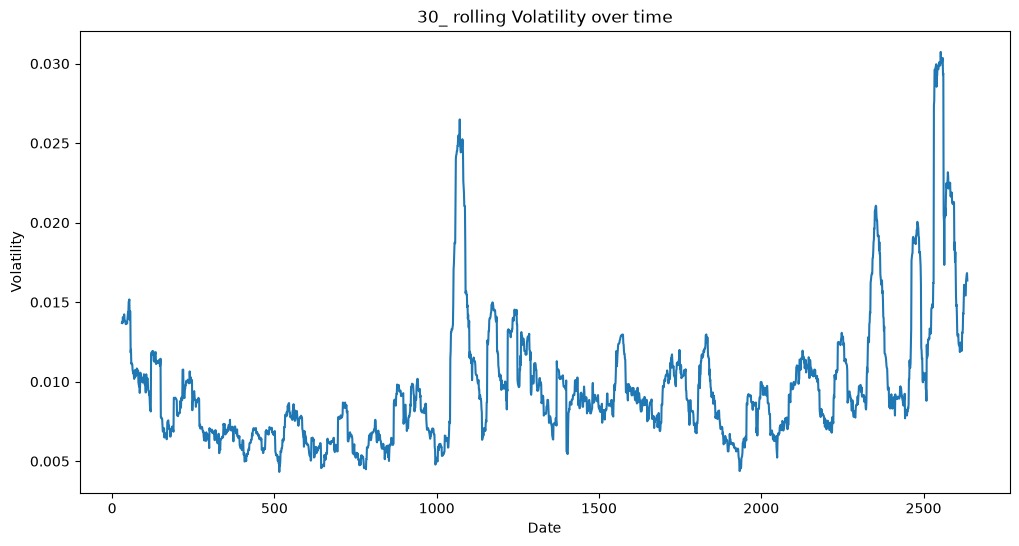

In [29]:
df["30_Volatility"]=df["Daily_return"].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df["30_Volatility"],label=("30 rolling volatilty"))
plt.title("30_ rolling Volatility over time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

High peaks which are show in 2020 and 2026 shows a high volatilty which indicates high fluctuations of gold prices.The low peaks
shows low volatilty which indicates the markets are stable 

The volatility plot shows periods where gold prices experienced larger day-to-day fluctuations. Higher volatility indicates greater market uncertainty, while lower volatility suggests more stable price movements. Volatility tends to increase during periods of strong price trends or major economic events.

In [30]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_range',
       'Daily_return', '7_Ma', '30_Ma', '30_Volatility'],
      dtype='str')
